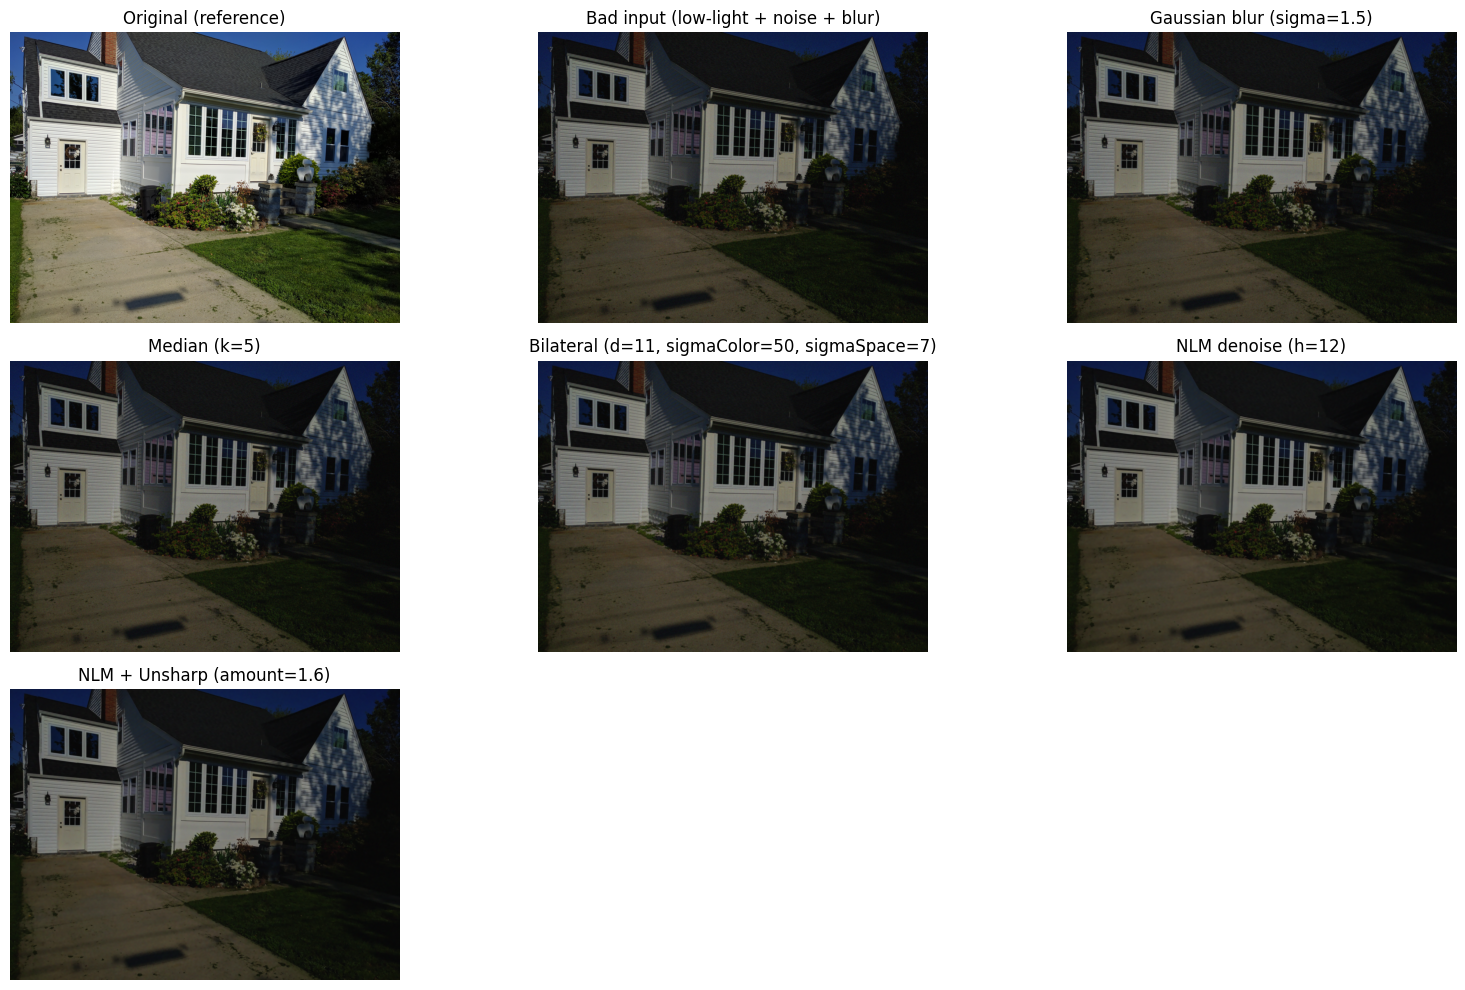

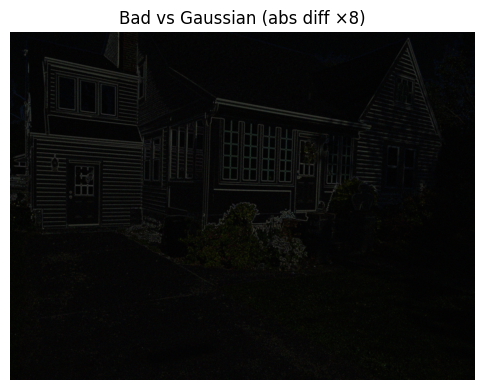

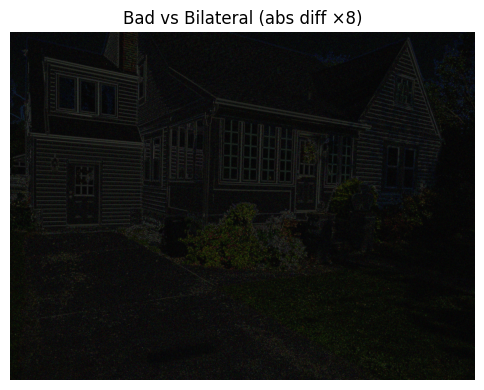

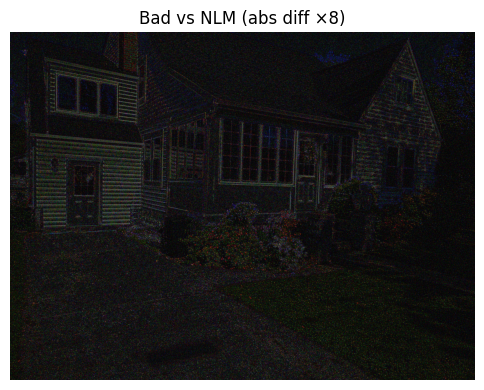

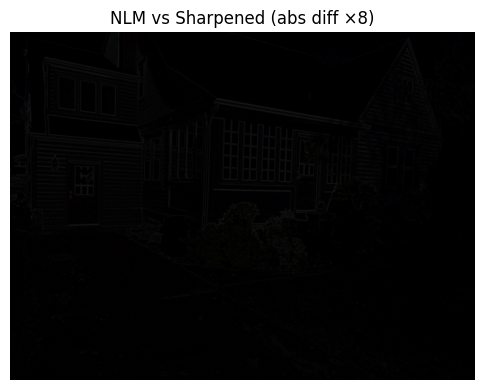

In [1]:
# Ex 3.12 — Sharpening, blur, and noise removal (OpenCV, full runnable code)
# This script:
# 1) Loads houses_3.jpg
# 2) Creates a clearly degraded "low-light noisy + blurry" version
# 3) Applies Gaussian blur, Median, Bilateral, and NLM denoising
# 4) Sharpens using Unsharp Mask (after denoising)
# 5) Displays everything + optional difference images

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Load image
# ----------------------------
img_path = os.path.join("..", "Files", "Random_Images", "houses_3.jpg")
bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
if bgr is None:
    raise FileNotFoundError(f"Could not read: {img_path}")
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

# ----------------------------
# Make a strong degraded version (so improvements are visible)
# ----------------------------
rng = np.random.default_rng(0)

bad = rgb.astype(np.float32) / 255.0

# darken midtones (simulate low light)
bad = bad ** 1.6
bad = bad * 0.6

# add Gaussian sensor-like noise (stronger than typical)
noise = rng.normal(0.0, 0.08, size=bad.shape).astype(np.float32)  # 0.08 is heavy
bad = np.clip(bad + noise, 0.0, 1.0)

# blur (defocus / motion-ish)
bad_u8 = (bad * 255.0 + 0.5).astype(np.uint8)
bad_u8 = cv2.GaussianBlur(bad_u8, (0, 0), 2.0)

# ----------------------------
# Filters (this is the "2)" part, but fully self-contained)
# ----------------------------

# Gaussian blur (softening / baseline denoise, but blurs edges)
gauss = cv2.GaussianBlur(bad_u8, (0, 0), 1.5)

# Median filter (great for salt/pepper; moderate for Gaussian noise)
median = cv2.medianBlur(bad_u8, 5)

# Bilateral filter (edge-preserving smoothing)
# sigmaColor controls how different colors can be and still be averaged.
# sigmaSpace controls the spatial neighborhood influence.
bilat = cv2.bilateralFilter(bad_u8, d=11, sigmaColor=50, sigmaSpace=7)

# Non-local means denoising (often better for camera-like noise than bilateral)
nlm = cv2.fastNlMeansDenoisingColored(
    bad_u8, None,
    h=12, hColor=12,
    templateWindowSize=7,
    searchWindowSize=21
)

# Unsharp mask (sharpen AFTER denoise, otherwise you sharpen noise)
blur_for_sharp = cv2.GaussianBlur(nlm, (0, 0), 1.2)
sharp = cv2.addWeighted(nlm, 1.6, blur_for_sharp, -0.6, 0)

# ----------------------------
# Display grid
# ----------------------------
imgs = [rgb, bad_u8, gauss, median, bilat, nlm, sharp]
titles = [
    "Original (reference)",
    "Bad input (low-light + noise + blur)",
    "Gaussian blur (sigma=1.5)",
    "Median (k=5)",
    "Bilateral (d=11, sigmaColor=50, sigmaSpace=7)",
    "NLM denoise (h=12)",
    "NLM + Unsharp (amount=1.6)"
]

plt.figure(figsize=(16, 10))
for i, (im, t) in enumerate(zip(imgs, titles), start=1):
    plt.subplot(3, 3, i)
    plt.imshow(im)
    plt.title(t)
    plt.axis("off")
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: show difference images (makes subtle changes visible)
# ----------------------------
def show_diff(a_u8, b_u8, title, scale=8.0):
    a = a_u8.astype(np.float32) / 255.0
    b = b_u8.astype(np.float32) / 255.0
    d = np.clip(np.abs(a - b) * scale, 0.0, 1.0)
    plt.figure(figsize=(6, 4))
    plt.imshow(d)
    plt.title(f"{title} (abs diff ×{scale:g})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

show_diff(bad_u8, gauss, "Bad vs Gaussian")
show_diff(bad_u8, bilat, "Bad vs Bilateral")
show_diff(bad_u8, nlm, "Bad vs NLM")
show_diff(nlm, sharp, "NLM vs Sharpened")
